# Trial 3 Explanation

Now since the focus moves to only the post-COVID years.

In [1]:
import os
import joblib
import warnings
os.environ["OMP_NUM_THREADS"] = "1"
import numpy as np
import pandas as pd
import seaborn as sns
import geopandas as gpd
from google.colab import files
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import RFE
from sklearn.metrics import silhouette_score
from sklearn.linear_model import ElasticNetCV
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score, KFold
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [2]:
# Open a file upload dialog
uploaded = files.upload()

Saving Cleaned Dataset.csv to Cleaned Dataset.csv


In [3]:
dataset = pd.read_csv("Cleaned Dataset.csv")

In [4]:
dataset.head()

,Country,Year,BEV Percentage (Total Number Of Registrations),BEV (New Registrations),GDP,CPI,EG,Recharging Points,AC Recharging Speed (km/h),DC Recharging Speed (km/h),...,Real Range,Purchase price (EUR),Log_BEV Percentage (Total Number Of Registrations),Log_BEV (New Registrations),Log_Recharging Points,Log_GDP,Log_CPI,Log_Available,Log_DC Recharging Speed (km/h),YJ_Purchase price (EUR)
0,Austria,2011,0.18,631.0,308167.0,3.286579,1.6,963,17.500000,175.000000,...,95.00,30469.93,0.165514,6.448889,6.871091,12.638400,1.455489,1.609438,5.170484,-1.493084
1,Austria,2012,0.13,427.0,316589.4,2.485676,1.0,1063,29.169521,217.394139,...,95.00,30469.93,0.122218,6.059123,6.969791,12.665364,1.248662,1.609438,5.386301,-1.493084
2,Austria,2013,0.21,656.0,321191.7,2.000156,0.4,1173,48.200000,270.000000,...,142.22,30469.93,0.190620,6.487684,7.068172,12.679797,1.098664,2.197225,5.602119,-1.493084
3,Austria,2014,0.44,1344.0,330113.5,1.605812,1.0,1393,22.600000,240.000000,...,155.77,35555.64,0.364643,7.204149,7.239933,12.707195,0.957744,2.639057,5.484797,-0.885657
4,Austria,2015,0.55,1699.0,342083.5,0.896563,0.6,1625,47.700000,381.250000,...,215.22,42052.00,0.438255,7.438384,7.393878,12.742813,0.640043,3.091042,5.946075,0.277809


In [5]:
dataset.columns

Index(['Country', 'Year', 'BEV Percentage (Total Number Of Registrations)',
       'BEV (New Registrations)', 'GDP', 'CPI', 'EG', 'Recharging Points',
       'AC Recharging Speed (km/h)', 'DC Recharging Speed (km/h)', 'Available',
       'Battery Capacity', 'Real Range', 'Purchase price (EUR)',
       'Log_BEV Percentage (Total Number Of Registrations)',
       'Log_BEV (New Registrations)', 'Log_Recharging Points', 'Log_GDP',
       'Log_CPI', 'Log_Available', 'Log_DC Recharging Speed (km/h)',
       'YJ_Purchase price (EUR)'],
      dtype='object')

# Feature Selection

In [6]:
# Split the dataset
train = dataset[dataset['Year'].between(2020, 2023)].copy()
test = dataset[dataset['Year'] >= 2024].copy()

In [7]:
features = [
    'Log_Recharging Points',
    'Real Range',
    'Log_Available',
    'YJ_Purchase price (EUR)',
    'AC Recharging Speed (km/h)',
    'Battery Capacity',
    'Log_DC Recharging Speed (km/h)',
    'EG',
    'Log_GDP',
    'Log_CPI'
]

**1. Heat Maps with Pearson Correlation**

Helps in understanding correlation of the features

Correlation of selected features with Log_BEV Percentage (Total Number Of Registrations) on years from 2020 - 2023:

Log_Recharging Points             0.616737
Log_Available                     0.484056
YJ_Purchase price (EUR)           0.482164
Battery Capacity                  0.480464
Log_DC Recharging Speed (km/h)    0.478512
Real Range                        0.478189
AC Recharging Speed (km/h)        0.443725
EG                                0.306484
Log_GDP                           0.273294
Log_CPI                           0.247722
Name: Log_BEV Percentage (Total Number Of Registrations), dtype: float64


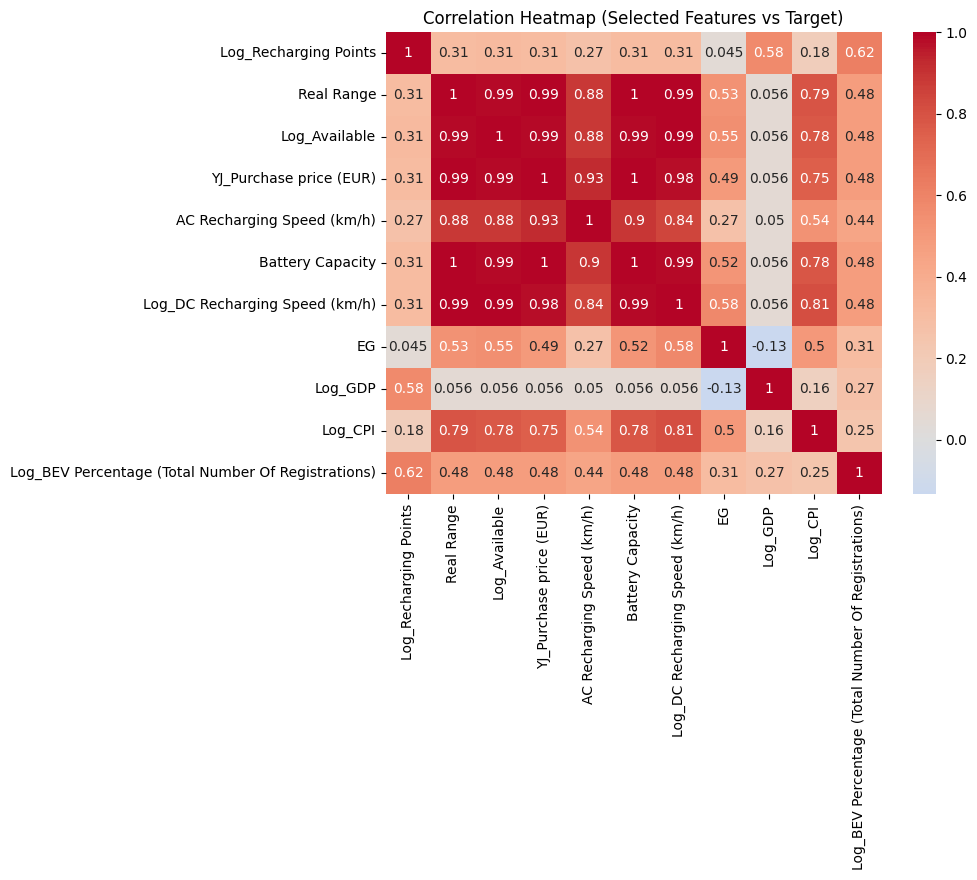

In [8]:
# Define the target
target = 'Log_BEV Percentage (Total Number Of Registrations)'

# Compute correlation only for selected features + target
corr = train[features + [target]].corr(numeric_only=True)[target].sort_values(ascending=False)

# Drop the target itself if it appears
corr = corr.drop(labels=[target], errors='ignore')

# Display correlations
print("Correlation of selected features with Log_BEV Percentage (Total Number Of Registrations) on years from 2020 - 2023:\n")
print(corr)

# Visualize heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(train[features + [target]].corr(numeric_only=True),
            annot=True, cmap='coolwarm', center=0)
plt.title("Correlation Heatmap (Selected Features vs Target)")
plt.show()

In [9]:
train[['Log_BEV Percentage (Total Number Of Registrations)',
         'Log_BEV (New Registrations)']].corr()

,Log_BEV Percentage (Total Number Of Registrations),Log_BEV (New Registrations)
Log_BEV Percentage (Total Number Of Registrations),1.000000,0.723528
Log_BEV (New Registrations),0.723528,1.000000


**2. Multicollinearity**

Removal of redundant features

In [10]:
train_features = dataset[features].dropna().reset_index(drop=True)

train_vif_data = pd.DataFrame()
train_vif_data["Feature"] = train_features.columns
train_vif_data["VIF"] = [variance_inflation_factor(train_features.values, i) for i in range(train_features.shape[1])]
print(train_vif_data)

                          Feature         VIF
0           Log_Recharging Points   17.045261
1                      Real Range  537.361825
2                   Log_Available  115.978308
3         YJ_Purchase price (EUR)    4.666438
4      AC Recharging Speed (km/h)   39.427131
5                Battery Capacity  271.273113
6  Log_DC Recharging Speed (km/h)  131.906094
7                              EG    1.782205
8                         Log_GDP   56.511499
9                         Log_CPI    3.290362


**3. Principal Component Analysis (PCA)**

To reduce the dimensions and deal with multicollinearity. This also will help us resolve the conflict of high correlation with sales but also high VIF.

**Refer paper : A Tutorial on Principal Component Analysisn to understand the PCA concept**

## Mathematics For PCA

**Step 1: Covariance Matrix**  
Calculates the covariance matrix for the features to see the relationship among themselves. Since we also have average features like "Real Range" and "Battery Capacity" which go hand in hand as verfied previously using heatmap and VIF.

**Step 2: Eigen Value decomposition and determine Eigen Vectors**
Formula: determinant|(A - $\lambda$.I)| = 0

**Step 3: Normalise the Eigen Vectors**
Point to remember: Discarding the eigenvector v2 and so on, will reduce dimensionality leading to loss of information. Therefore here we used Elbow Method to get the significant eigen vectors to prevent this.

**Step 4: Find the Principal Components**
Here,  the aim is to use the feature vector formed using the eigenvectors of the covariance matrix, to reorient the data from the original axes to the ones represented by the principal components (hence the name Principal Components Analysis).

Formula: Final Dataset = Feature Vector (Step 3) * Normalised Original Dataset (Step 3)

In [11]:
# Check which columns have NaNs and how many
print("Missing Values Per Column on Train data (2020-2023)")
print(train[features].isna().sum())

print("\nMissing Values Per Column Test data (2024)")
print(test[features].isna().sum())

Missing Values Per Column on Train data (2020-2023)
Log_Recharging Points             0
Real Range                        0
Log_Available                     0
YJ_Purchase price (EUR)           0
AC Recharging Speed (km/h)        0
Battery Capacity                  0
Log_DC Recharging Speed (km/h)    0
EG                                0
Log_GDP                           0
Log_CPI                           1
dtype: int64

Missing Values Per Column Test data (2024)
Log_Recharging Points             0
Real Range                        0
Log_Available                     0
YJ_Purchase price (EUR)           0
AC Recharging Speed (km/h)        0
Battery Capacity                  0
Log_DC Recharging Speed (km/h)    0
EG                                0
Log_GDP                           0
Log_CPI                           0
dtype: int64


In [12]:
# Checking which rows are empty
print("Missing Log_CPI in Train data (2020-2023)")
print(train[train['Log_CPI'].isna()].reset_index()[['Country', 'Year', 'Log_CPI']])

Missing Log_CPI in Train data (2020-2023)
  Country  Year  Log_CPI
0  Greece  2020      NaN


In [13]:
# Imputation for Log_CPI NaNs by filling the spaces with the median

# Calculate the median Log_CPI for every country of train data
country_medians = train.groupby('Country')['Log_CPI'].median()

# Function to fill the gaps
def impute_by_country(df):
    df_clean = df.copy()

    # Loop through the data, if Log_CPI is missing, we look up that specific country's median from our 'country_medians' list.
    df_clean['Log_CPI'] = df_clean['Log_CPI'].fillna(df_clean['Country'].map(country_medians))

    return df_clean

# Apply the fix to train dataset
train_fixed = impute_by_country(train)
test_fixed = impute_by_country(test)

# Extract 10 features
X_train_imputed = train_fixed[features]
X_test_imputed = test_fixed[features]

In [14]:
# Verfication
print("Missing Values Per Column on Train data (2020-2023)")
print(train_fixed[features].isna().sum())

print("\nMissing Values Per Column Test data (2024)")
print(test_fixed[features].isna().sum())

Missing Values Per Column on Train data (2020-2023)
Log_Recharging Points             0
Real Range                        0
Log_Available                     0
YJ_Purchase price (EUR)           0
AC Recharging Speed (km/h)        0
Battery Capacity                  0
Log_DC Recharging Speed (km/h)    0
EG                                0
Log_GDP                           0
Log_CPI                           0
dtype: int64

Missing Values Per Column Test data (2024)
Log_Recharging Points             0
Real Range                        0
Log_Available                     0
YJ_Purchase price (EUR)           0
AC Recharging Speed (km/h)        0
Battery Capacity                  0
Log_DC Recharging Speed (km/h)    0
EG                                0
Log_GDP                           0
Log_CPI                           0
dtype: int64


In [15]:
# Standard Scaling to bring everything in one unit after imputing the dataset
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imputed)
X_test_scaled = scaler.transform(X_test_imputed)

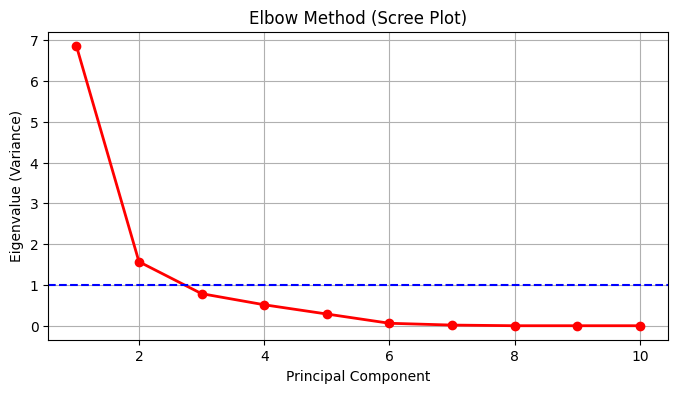

In [16]:
# Elbow Method to justify the number of components
pca_full = PCA() # We fit all 10 components first to see the curve
pca_full.fit(X_train_scaled)
eigenvalues = pca_full.explained_variance_

plt.figure(figsize=(8, 4))
plt.plot(range(1, len(eigenvalues) + 1), eigenvalues, 'ro-', linewidth=2)
plt.axhline(y=1, color='blue', linestyle='--')
plt.title('Elbow Method (Scree Plot)')
plt.xlabel('Principal Component')
plt.ylabel('Eigenvalue (Variance)')
plt.grid(True)
plt.show()

The logic here is we have kept only those eigenvalues which above the "elbow" (or above lambda = 1).

Mathematically discarding the Eigenvectors v3 to v10.

In [17]:
# PCA
principal_components = 2 # Based on the elbow method for not missing out on any features
pca = PCA(n_components=principal_components)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

In [18]:
# Convert to Final Dataset for your Prediction Model
pc_columns = [f'PC{i+1}' for i in range(X_train_pca.shape[1])]

X_train_final = pd.DataFrame(X_train_pca, columns=pc_columns, index=train.index)
X_test_final = pd.DataFrame(X_test_pca, columns=pc_columns, index=test.index)

In [19]:
# Define target
y_train = train['Log_BEV Percentage (Total Number Of Registrations)']
y_test = test['Log_BEV Percentage (Total Number Of Registrations)']

print(f"{len(features)} features reduced to {len(pc_columns)} Principal Components.")
print(f"Variance Explained: {pca.explained_variance_ratio_.sum():.2%}")

10 features reduced to 2 Principal Components.
Variance Explained: 83.53%


**For Train:** Python takes the 2020–2023 data and multiplies it by the top 2 Eigenvectors to get the X_train_final coordinates.

**For Test:** Code does not solve $|A - lambda I| = 0 for the Test set. Instead, it takes the Feature Vector (Eigenvectors) discovered in the Training set and multiplies it by the 2024 data. This prevents data leakage.

In [20]:
# Check which PC is the strongest predictor of sales
pc_correlation = X_train_final.corrwith(y_train)
print("Correlation of Principal Components with BEV Sales:")
print(pc_correlation.sort_values(ascending=False))

Correlation of Principal Components with BEV Sales:
PC1    0.497976
PC2    0.357691
dtype: float64


In [21]:
# Features along with their weights in each principal component columns explaining their variance.
loadings_table = pd.DataFrame(
    pca.components_.T,
    columns=['PC1', 'PC2'],
    index=features
)

# Display the final table
print("Loading factors of the parameters selected (Feature Weights)")
print(loadings_table.round(4))

Loading factors of the parameters selected (Feature Weights)
                                   PC1     PC2
Log_Recharging Points           0.1316  0.6440
Real Range                      0.3812 -0.0286
Log_Available                   0.3805 -0.0277
YJ_Purchase price (EUR)         0.3797 -0.0210
AC Recharging Speed (km/h)      0.3361  0.0092
Battery Capacity                0.3813 -0.0262
Log_DC Recharging Speed (km/h)  0.3809 -0.0343
EG                              0.2179 -0.2635
Log_GDP                         0.0376  0.7153
Log_CPI                         0.3100 -0.0157


In [22]:
# To confirm that all the principal components are independent of each other.
vif_data = pd.DataFrame()
vif_data["Feature"] = X_train_final.columns

# Calculate VIF for each Principal Component
vif_data["VIF"] = [variance_inflation_factor(X_train_final.values, i)
                   for i in range(len(X_train_final.columns))]

print("VIF for Principal Components")
print(vif_data)

VIF for Principal Components
  Feature  VIF
0     PC1  1.0
1     PC2  1.0


In [23]:
# Saving the PCA model
# Define filenames
csv_files = ['X_train_pca.csv', 'X_test_pca.csv', 'y_train.csv', 'y_test.csv']
pkl_file = 'pca_processors.pkl'

# Save the processed Datasets
X_train_final.to_csv(csv_files[0], index=True)
X_test_final.to_csv(csv_files[1], index=True)
y_train.to_csv(csv_files[2], index=True)
y_test.to_csv(csv_files[3], index=True)

# Save the PCA
pca_processing_tools = {
    'country_medians': country_medians,
    'scaler': scaler,
    'pca_model': pca,
    'feature_names': features
}
joblib.dump(pca_processing_tools, pkl_file)

# Just to be sure print the exact file locations
print(f"Folder Location: {os.getcwd()}")
print("-" * 30)

for file in csv_files + [pkl_file]:
    full_path = os.path.abspath(file)
    print(f"Saved: {file}")
    print(f"Full Path: {full_path}\n")

Folder Location: /content
------------------------------
Saved: X_train_pca.csv
Full Path: /content/X_train_pca.csv

Saved: X_test_pca.csv
Full Path: /content/X_test_pca.csv

Saved: y_train.csv
Full Path: /content/y_train.csv

Saved: y_test.csv
Full Path: /content/y_test.csv

Saved: pca_processors.pkl
Full Path: /content/pca_processors.pkl



# Clustering

In [24]:
# Load PCA tools and feature definitions
tools = joblib.load("pca_processors.pkl")

scaler = tools['scaler']
pca = tools['pca_model']
country_medians = tools['country_medians']
features = tools['feature_names']

Understanding train data and test data

In [25]:
train_data = dataset[dataset['Year'].between(2020, 2023)].copy()
test_data = dataset[dataset['Year'] >= 2024].copy()

In [26]:
# Aggregate numeric features per country
train_country = train_data.groupby('Country')[features].mean(numeric_only=True)
test_country = test_data.groupby('Country')[features].mean(numeric_only=True)

print(f"Train dataset shape: {train_country.shape}")
print(f"Test dataset shape: {test_country.shape}")

Train dataset shape: (27, 10)
Test dataset shape: (27, 10)


1. Each country now appears once per period.
2. Each feature represents that country’s average condition during the period.

In [27]:
# Apply the same scaling and PCA
X_pre_scaled = scaler.transform(train_country)
X_post_scaled = scaler.transform(test_country)

X_pre_pca = pca.transform(X_pre_scaled)
X_post_pca = pca.transform(X_post_scaled)

print(f"PCA-transformed shapes: Train={X_pre_pca.shape}, Test={X_post_pca.shape}")

PCA-transformed shapes: Train=(27, 2), Test=(27, 2)


## 1. K-Means

**Refer paper: Analysis of Techniques for Selecting Appropriate Number of Clusters in k-means Clustering Algorithm** to cite why I chose these 2 methods.

Elbow Method

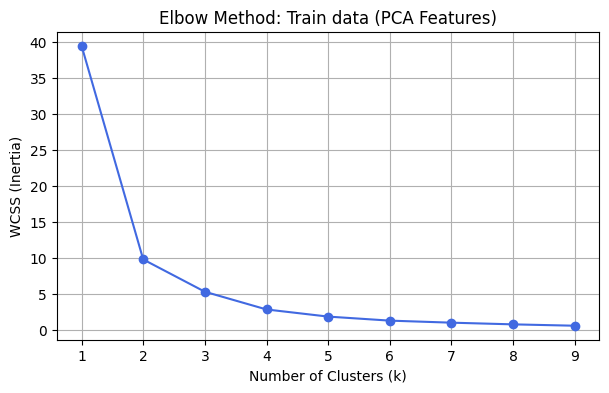

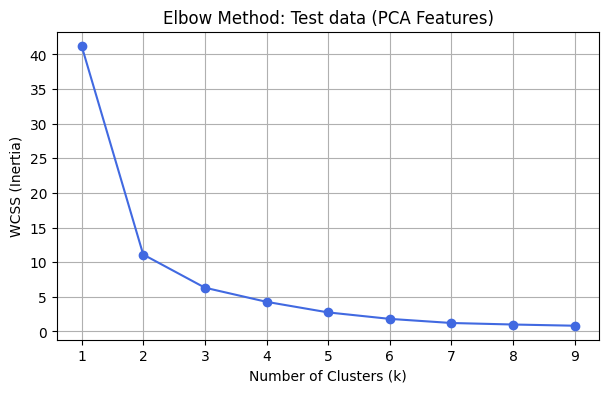

In [28]:
# Elbow Method (to find optimal k)
def plot_elbow(X, label):
    inertia = []
    K_range = range(1, 10)
    for k in K_range:
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        kmeans.fit(X)
        inertia.append(kmeans.inertia_)
    plt.figure(figsize=(7, 4))
    plt.plot(K_range, inertia, 'o-', color='royalblue')
    plt.title(f'Elbow Method: {label}')
    plt.xlabel('Number of Clusters (k)')
    plt.ylabel('WCSS (Inertia)')
    plt.grid(True)
    plt.show()

plot_elbow(X_pre_pca, "Train data (PCA Features)")
plot_elbow(X_post_pca, "Test data (PCA Features)")

Use of SILHOUETTE method to verify the #clusters in eblow method

**This is the validation method to the elbow method.**

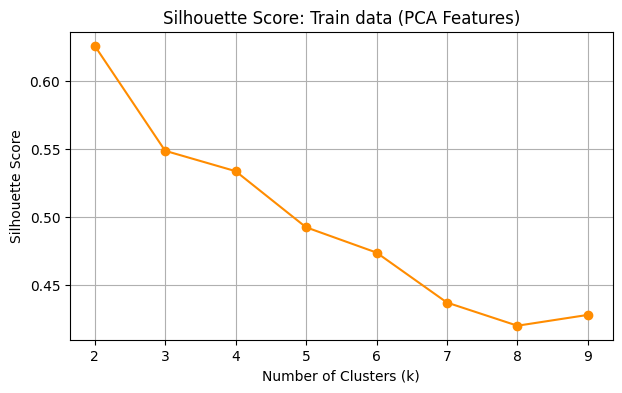

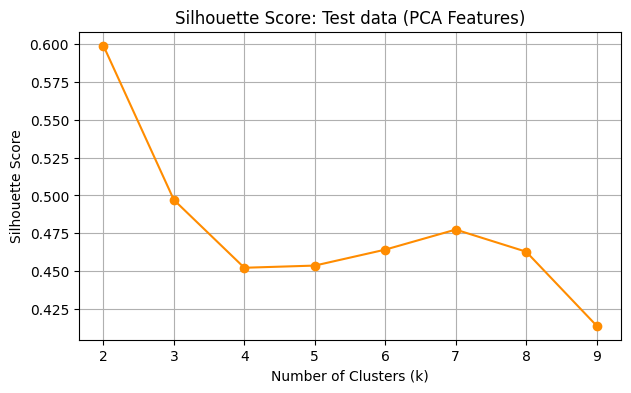

In [29]:
# Silhouette Method (to validate optimal k)
def plot_silhouette(X, label):
    sil_scores = []
    K_range = range(2, 10)
    for k in K_range:
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = kmeans.fit_predict(X)
        sil = silhouette_score(X, labels)
        sil_scores.append(sil)
    plt.figure(figsize=(7, 4))
    plt.plot(K_range, sil_scores, 'o-', color='darkorange')
    plt.title(f'Silhouette Score: {label}')
    plt.xlabel('Number of Clusters (k)')
    plt.ylabel('Silhouette Score')
    plt.grid(True)
    plt.show()

plot_silhouette(X_pre_pca, "Train data (PCA Features)")
plot_silhouette(X_post_pca, "Test data (PCA Features)")

In [30]:
# Final Clustering
n_clusters = 2

kmeans_pre = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
kmeans_post = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)

train_country['Cluster'] = kmeans_pre.fit_predict(X_pre_pca)
test_country['Cluster'] = kmeans_post.fit_predict(X_post_pca)

In [31]:
# Compare cluster memberships pre vs post COVID
cluster_compare = train_country[['Cluster']].rename(columns={'Cluster': 'Train_Cluster'})
cluster_compare['Test_Cluster'] = test_country['Cluster']
print(cluster_compare)

                Train_Cluster  Test_Cluster
Country                                    
Austria                     0             1
Belgium                     0             1
Bulgaria                    1             0
Croatia                     1             0
Cyprus                      1             0
Czech Republic              0             1
Denmark                     0             1
Estonia                     1             0
Finland                     0             1
France                      0             1
Germany                     0             1
Greece                      1             0
Hungary                     0             1
Ireland                     1             0
Italy                       0             1
Latvia                      1             0
Lithuania                   1             0
Luxembourg                  1             0
Malta                       1             0
Netherlands                 0             1
Poland                      0   

In [32]:
# Print which countries changed clusters
print("\nCountries that changed clusters from Train to Test Cluster:\n")
for c in cluster_compare.index:
    pre_c = cluster_compare.loc[c, 'Train_Cluster']
    post_c = cluster_compare.loc[c, 'Test_Cluster']
    if pre_c != post_c:
        print(f"  - {c}: {pre_c} ---> {post_c}")


Countries that changed clusters from Train to Test Cluster:

  - Austria: 0 ---> 1
  - Belgium: 0 ---> 1
  - Bulgaria: 1 ---> 0
  - Croatia: 1 ---> 0
  - Cyprus: 1 ---> 0
  - Czech Republic: 0 ---> 1
  - Denmark: 0 ---> 1
  - Estonia: 1 ---> 0
  - Finland: 0 ---> 1
  - France: 0 ---> 1
  - Germany: 0 ---> 1
  - Greece: 1 ---> 0
  - Hungary: 0 ---> 1
  - Ireland: 1 ---> 0
  - Italy: 0 ---> 1
  - Latvia: 1 ---> 0
  - Lithuania: 1 ---> 0
  - Luxembourg: 1 ---> 0
  - Malta: 1 ---> 0
  - Netherlands: 0 ---> 1
  - Poland: 0 ---> 1
  - Portugal: 0 ---> 1
  - Romania: 0 ---> 1
  - Slovakia: 1 ---> 0
  - Slovenia: 1 ---> 0
  - Spain: 0 ---> 1
  - Sweden: 0 ---> 1


In [33]:
# Print which stable countries
stable_count = 0

for c in cluster_compare.index:
    pre_c = cluster_compare.loc[c, 'Train_Cluster']
    post_c = cluster_compare.loc[c, 'Test_Cluster']

    # If the clusters are the same
    if pre_c == post_c:
        print(f"  - {c}: Stayed in Cluster {pre_c}")
        stable_count += 1

In [34]:
# Check mean PC scores for each cluster Train data and Test data

# Merge the PCA values back into our country summaries
pre_analysis = pd.DataFrame(X_pre_pca, columns=['PC1', 'PC2'], index=train_country.index)
pre_analysis['Cluster'] = train_country['Cluster']

post_analysis = pd.DataFrame(X_post_pca, columns=['PC1', 'PC2'], index=test_country.index)
post_analysis['Cluster'] = test_country['Cluster']

# Print the Centroids characteristics as per the PCA
print("Train Data (2020-2023) Cluster Centroids (Mean PCA Scores)")
print(pre_analysis.groupby('Cluster').mean())
print()
print("Test Data (2024) Cluster Centroids (Mean PCA Scores)")
print(post_analysis.groupby('Cluster').mean())

Train Data (2020-2023) Cluster Centroids (Mean PCA Scores)
              PC1       PC2
Cluster                    
0        0.077620  0.934827
1       -0.096595 -1.168555

Test Data (2024) Cluster Centroids (Mean PCA Scores)
              PC1       PC2
Cluster                    
0        4.151118 -0.918533
1        4.334010  1.200408


In [35]:
# Preparing the data for plotting by ensuring PC scores and Clusters are aligned

# List of unique countries in the correct order
pre_countries_list = train_country.index
post_countries_list = test_country.index

# Create DataFrames for plotting using the PCA results
pre_plot_data = pd.DataFrame(X_pre_pca, columns=['PC1', 'PC2'], index=pre_countries_list)
pre_plot_data['Cluster'] = train_country['Cluster']

post_plot_data = pd.DataFrame(X_post_pca, columns=['PC1', 'PC2'], index=post_countries_list)
post_plot_data['Cluster'] = test_country['Cluster']

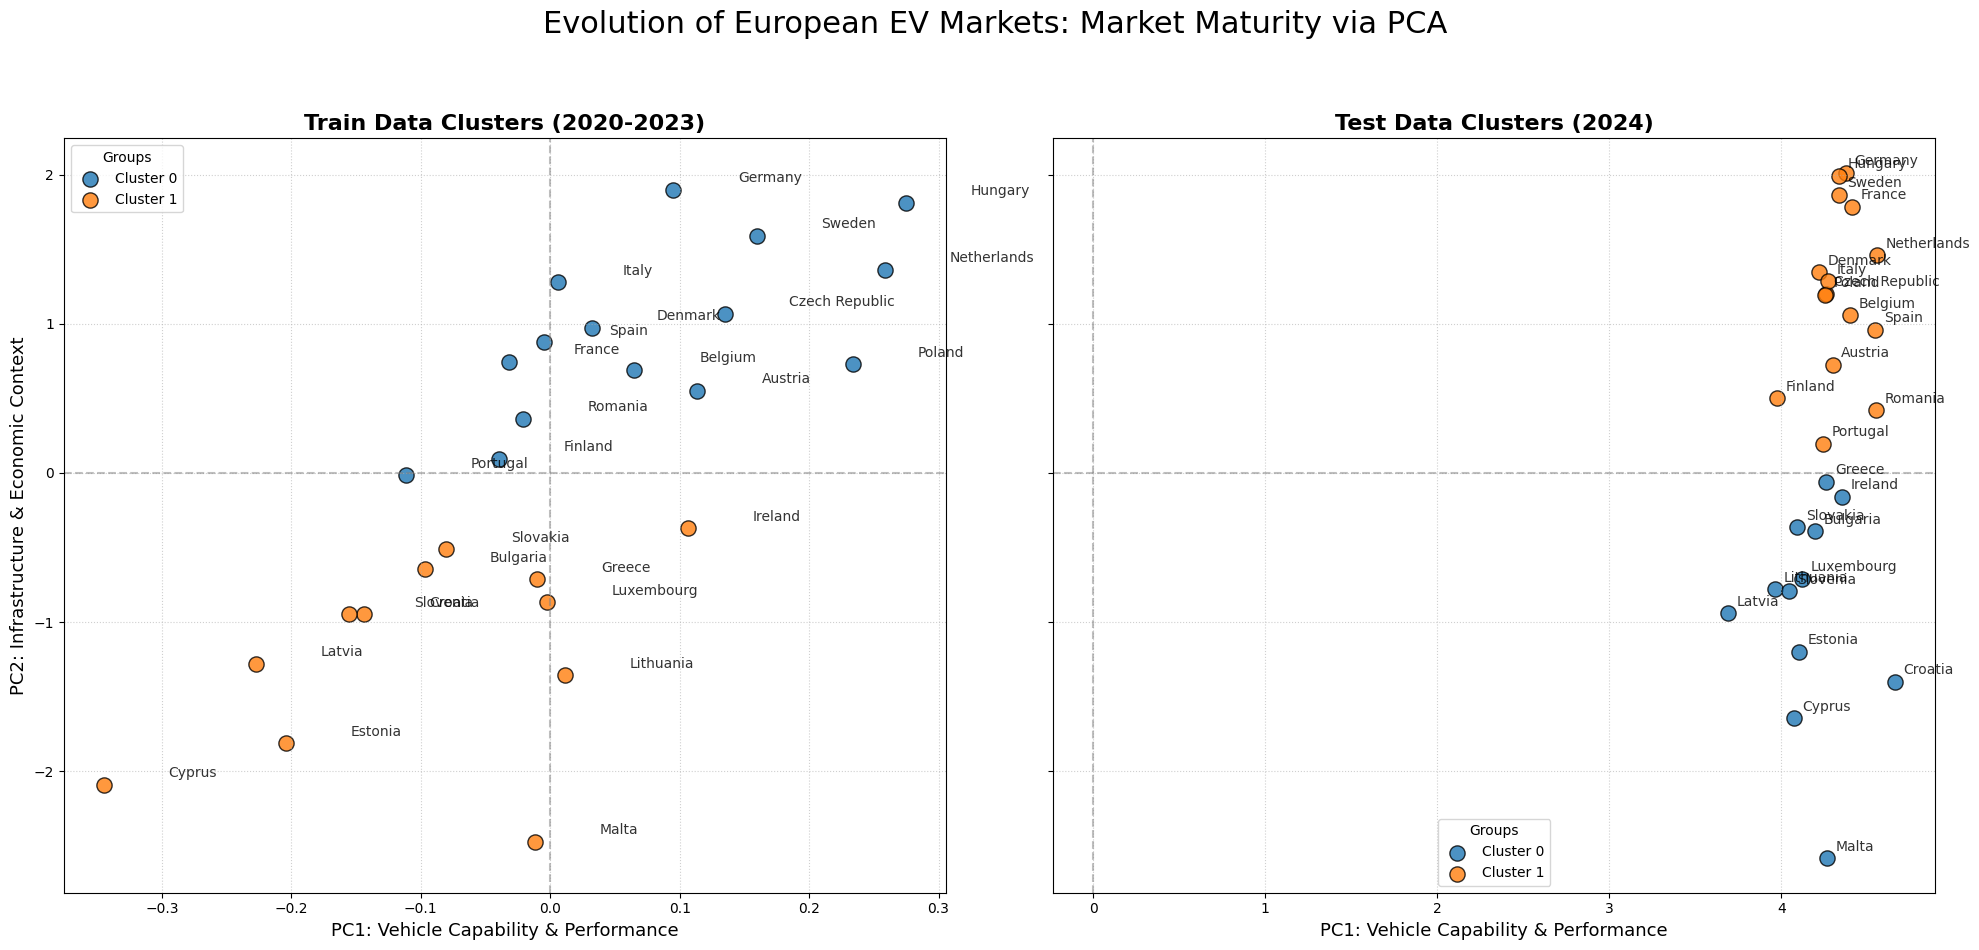

In [36]:
# Visualization Plotting
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 9), sharey=True, dpi=100)

# Train Data: 2011-2022
for cluster in [0, 1]:
    subset = pre_plot_data[pre_plot_data['Cluster'] == cluster]
    ax1.scatter(subset['PC1'], subset['PC2'], label=f'Cluster {cluster}', s=120, edgecolors='black', alpha=0.8)

# Add country labels for Train data
for country in pre_plot_data.index:
    row = pre_plot_data.loc[country]
    ax1.text(row['PC1'] + 0.05, row['PC2'] + 0.05, country, fontsize=10, alpha=0.8)

ax1.set_title('Train Data Clusters (2020-2023)', fontsize=16, fontweight='bold')
ax1.set_xlabel('PC1: Vehicle Capability & Performance', fontsize=13)
ax1.set_ylabel('PC2: Infrastructure & Economic Context', fontsize=13)
ax1.axvline(0, color='gray', linestyle='--', alpha=0.5)
ax1.axhline(0, color='gray', linestyle='--', alpha=0.5)
ax1.grid(True, linestyle=':', alpha=0.6)
ax1.legend(title="Groups")

# Test Data: 2023-2024
for cluster in [0, 1]:
    subset = post_plot_data[post_plot_data['Cluster'] == cluster]
    ax2.scatter(subset['PC1'], subset['PC2'], label=f'Cluster {cluster}', s=120, edgecolors='black', alpha=0.8)

# Add country labels for Test data
for country in post_plot_data.index:
    row = post_plot_data.loc[country]
    ax2.text(row['PC1'] + 0.05, row['PC2'] + 0.05, country, fontsize=10, alpha=0.8)

ax2.set_title('Test Data Clusters (2024)', fontsize=16, fontweight='bold')
ax2.set_xlabel('PC1: Vehicle Capability & Performance', fontsize=13)
ax2.axvline(0, color='gray', linestyle='--', alpha=0.5)
ax2.axhline(0, color='gray', linestyle='--', alpha=0.5)
ax2.grid(True, linestyle=':', alpha=0.6)
ax2.legend(title="Groups")

plt.suptitle('Evolution of European EV Markets: Market Maturity via PCA', fontsize=22, y=1.05)
plt.tight_layout()
plt.show()

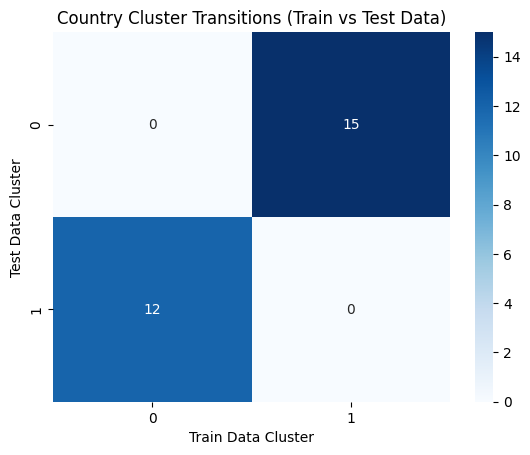

In [37]:
# Heatmap to visualize cluster transitions
ct = pd.crosstab(cluster_compare['Train_Cluster'], cluster_compare['Test_Cluster'])
sns.heatmap(ct, annot=True, fmt='d', cmap='Blues')
plt.title('Country Cluster Transitions (Train vs Test Data)')
plt.xlabel('Train Data Cluster')
plt.ylabel('Test Data Cluster')
plt.show()

## 2. DBSCAN

**Parameters:**
1. eps=1.2: A point is a neighbor if the distance is <= 1.2
2. min_samples=2: A cluster needs at least 2 countries to exist

In [38]:
# Train clustering by inititalising the clusters and fitiing the model on the pca averages
dbscan_pre = DBSCAN(eps=0.8, min_samples=2)
pre_plot_data['DBSCAN_Cluster'] = dbscan_pre.fit_predict(X_pre_pca)

# Test clustering by inititalising the clusters and fitiing the model on the pca averages
dbscan_post = DBSCAN(eps=0.8, min_samples=2)
post_plot_data['DBSCAN_Cluster'] = dbscan_post.fit_predict(X_post_pca)

In [39]:
print("Train Cluster Characteristics:")
pre_characteristics = pre_plot_data.groupby('DBSCAN_Cluster')[['PC1', 'PC2']].mean()
display(pre_characteristics)

print("Test Cluster Characteristics:")
post_characteristics = post_plot_data.groupby('DBSCAN_Cluster')[['PC1', 'PC2']].mean()
display(post_characteristics)

Train Cluster Characteristics:


,PC1,PC2
DBSCAN_Cluster,,
0,0.000191,-0.00001


Test Cluster Characteristics:


,PC1,PC2
DBSCAN_Cluster,,
-1,4.264710,-2.585556
0,4.252264,0.368049


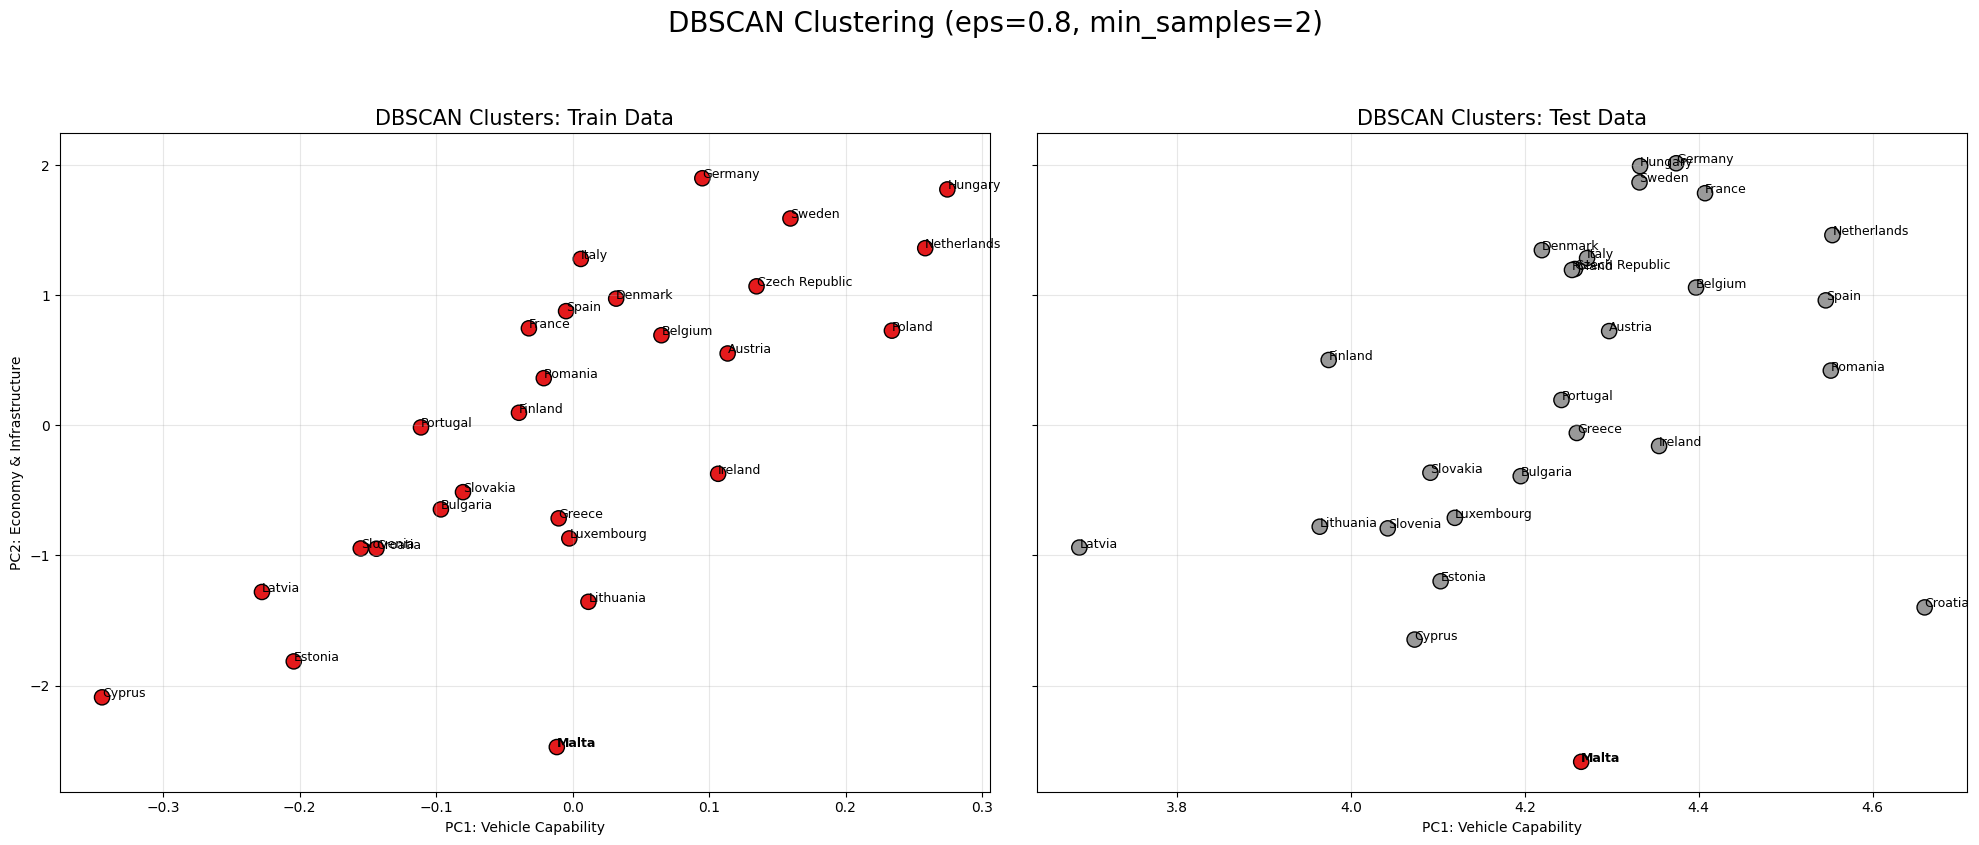

In [40]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8), sharey=True)

# Train visualisation
# Plot clusters and noise (-1)
scatter1 = ax1.scatter(pre_plot_data['PC1'], pre_plot_data['PC2'],
                       c=pre_plot_data['DBSCAN_Cluster'], cmap='Set1', s=120, edgecolors='black')

# Annotate Country names from the index
for country in pre_plot_data.index:
    ax1.text(pre_plot_data.loc[country, 'PC1'], pre_plot_data.loc[country, 'PC2'],
             country, fontsize=9, fontweight='bold' if country == 'Malta' else 'normal')

ax1.set_title('DBSCAN Clusters: Train Data', fontsize=15)
ax1.set_xlabel('PC1: Vehicle Capability')
ax1.set_ylabel('PC2: Economy & Infrastructure')
ax1.grid(True, alpha=0.3)

# Test visualisation
scatter2 = ax2.scatter(post_plot_data['PC1'], post_plot_data['PC2'],
                       c=post_plot_data['DBSCAN_Cluster'], cmap='Set1', s=120, edgecolors='black')

# Annotate Country names
for country in post_plot_data.index:
    ax2.text(post_plot_data.loc[country, 'PC1'], post_plot_data.loc[country, 'PC2'],
             country, fontsize=9, fontweight='bold' if country == 'Malta' else 'normal')

ax2.set_title('DBSCAN Clusters: Test Data', fontsize=15)
ax2.set_xlabel('PC1: Vehicle Capability')
ax2.grid(True, alpha=0.3)

# Final touches
plt.suptitle(f'DBSCAN Clustering (eps=0.8, min_samples=2)', fontsize=20, y=1.05)
plt.tight_layout()
plt.show()

In [41]:
# Merge Pre and Post COVID results on the Country index
dbscan_comparison = pre_plot_data[['DBSCAN_Cluster']].merge(
    post_plot_data[['DBSCAN_Cluster']],
    left_index=True,
    right_index=True,
    suffixes=('_Train', '_Test')
)

In [42]:
# Countries that changed clusters
dbscan_changed = dbscan_comparison[dbscan_comparison['DBSCAN_Cluster_Train'] != dbscan_comparison['DBSCAN_Cluster_Test']]
print(f"Total Countries that Changed Clusters: {len(dbscan_changed)}")
display(dbscan_changed)

Total Countries that Changed Clusters: 1


,DBSCAN_Cluster_Train,DBSCAN_Cluster_Test
Country,,
Malta,0,-1


In [43]:
# Countries that were stable
dbscan_stable = dbscan_comparison[dbscan_comparison['DBSCAN_Cluster_Train'] == dbscan_comparison['DBSCAN_Cluster_Test']]
print(f"Total Stable Countries: {len(dbscan_stable)}")
display(dbscan_stable)

Total Stable Countries: 26


,DBSCAN_Cluster_Train,DBSCAN_Cluster_Test
Country,,
Austria,0,0
Belgium,0,0
Bulgaria,0,0
Croatia,0,0
Cyprus,0,0
Czech Republic,0,0
Denmark,0,0
Estonia,0,0
Finland,0,0


## For Geopandas Visualisation

In [44]:
# Read Europe shapefile from GeoJSON (countries only)
url = "https://raw.githubusercontent.com/datasets/geo-countries/master/data/countries.geojson"
world = gpd.read_file(url)

print(world.columns)

Index(['name', 'ISO3166-1-Alpha-3', 'ISO3166-1-Alpha-2', 'geometry'], dtype='object')


In [45]:
# List of European countries
europe_countries = [
    "Austria", "Belgium", "Bulgaria", "Croatia", "Cyprus", "Czech Republic",
    "Denmark", "Estonia", "Finland", "France", "Germany", "Greece", "Hungary",
    "Ireland", "Italy", "Latvia", "Lithuania", "Luxembourg", "Malta",
    "Netherlands", "Poland", "Portugal", "Romania", "Slovakia", "Slovenia",
    "Spain", "Sweden"
]

# Replace 'name' with whatever column actually contains country names
europe = world[world['name'].isin(europe_countries)]

In [46]:
geo_data = europe.merge(dataset, left_on='name', right_on='Country', how='left')
geo_data = gpd.GeoDataFrame(geo_data, geometry='geometry')

In [47]:
print(geo_data.columns)

Index(['name', 'ISO3166-1-Alpha-3', 'ISO3166-1-Alpha-2', 'geometry', 'Country',
       'Year', 'BEV Percentage (Total Number Of Registrations)',
       'BEV (New Registrations)', 'GDP', 'CPI', 'EG', 'Recharging Points',
       'AC Recharging Speed (km/h)', 'DC Recharging Speed (km/h)', 'Available',
       'Battery Capacity', 'Real Range', 'Purchase price (EUR)',
       'Log_BEV Percentage (Total Number Of Registrations)',
       'Log_BEV (New Registrations)', 'Log_Recharging Points', 'Log_GDP',
       'Log_CPI', 'Log_Available', 'Log_DC Recharging Speed (km/h)',
       'YJ_Purchase price (EUR)'],
      dtype='object')


In [48]:
# Create Train Data summary
# We reset the index to turn 'Country' into a column and rename 'Cluster' to 'KMeans_Cluster'
pre_covid_summary = pre_plot_data.reset_index().rename(columns={
    'index': 'Country',
    'Cluster': 'KMeans_Cluster'
})[['Country', 'DBSCAN_Cluster', 'KMeans_Cluster']]

# Create Test Data summary
post_covid_summary = post_plot_data.reset_index().rename(columns={
    'index': 'Country',
    'Cluster': 'KMeans_Cluster'
})[['Country', 'DBSCAN_Cluster', 'KMeans_Cluster']]

print("Train Data K-Means and DBSCAN")
display(pre_covid_summary.head())
print()
print("Test Data K-Means and DBSCAN")
display(post_covid_summary.head())

Train Data K-Means and DBSCAN


,Country,DBSCAN_Cluster,KMeans_Cluster
0,Austria,0,0
1,Belgium,0,0
2,Bulgaria,0,1
3,Croatia,0,1
4,Cyprus,0,1



Test Data K-Means and DBSCAN


,Country,DBSCAN_Cluster,KMeans_Cluster
0,Austria,0,1
1,Belgium,0,1
2,Bulgaria,0,0
3,Croatia,0,0
4,Cyprus,0,0


In [49]:
# Create a fresh copy of your main dataset
dataset_clusters = dataset.copy()

# Merge Train Data clusters
dataset_clusters = dataset_clusters.merge(
    pre_covid_summary,
    on='Country',
    how='left'
).rename(columns={'DBSCAN_Cluster': 'DBSCAN_Train', 'KMeans_Cluster': 'KMeans_Train'})

# Merge Test Data clusters
dataset_clusters = dataset_clusters.merge(
    post_covid_summary,
    on='Country',
    how='left'
).rename(columns={'DBSCAN_Cluster': 'DBSCAN_Test', 'KMeans_Cluster': 'KMeans_Test'})

print("Merging complete. Columns in dataset_clusters:")
print(dataset_clusters.columns)

Merging complete. Columns in dataset_clusters:
Index(['Country', 'Year', 'BEV Percentage (Total Number Of Registrations)',
       'BEV (New Registrations)', 'GDP', 'CPI', 'EG', 'Recharging Points',
       'AC Recharging Speed (km/h)', 'DC Recharging Speed (km/h)', 'Available',
       'Battery Capacity', 'Real Range', 'Purchase price (EUR)',
       'Log_BEV Percentage (Total Number Of Registrations)',
       'Log_BEV (New Registrations)', 'Log_Recharging Points', 'Log_GDP',
       'Log_CPI', 'Log_Available', 'Log_DC Recharging Speed (km/h)',
       'YJ_Purchase price (EUR)', 'DBSCAN_Train', 'KMeans_Train',
       'DBSCAN_Test', 'KMeans_Test'],
      dtype='object')


In [50]:
geo_data = europe.merge(dataset_clusters, left_on='name', right_on='Country', how='left')
geo_data = gpd.GeoDataFrame(geo_data, geometry='geometry')

In [51]:
print(geo_data.columns.tolist())

['name', 'ISO3166-1-Alpha-3', 'ISO3166-1-Alpha-2', 'geometry', 'Country', 'Year', 'BEV Percentage (Total Number Of Registrations)', 'BEV (New Registrations)', 'GDP', 'CPI', 'EG', 'Recharging Points', 'AC Recharging Speed (km/h)', 'DC Recharging Speed (km/h)', 'Available', 'Battery Capacity', 'Real Range', 'Purchase price (EUR)', 'Log_BEV Percentage (Total Number Of Registrations)', 'Log_BEV (New Registrations)', 'Log_Recharging Points', 'Log_GDP', 'Log_CPI', 'Log_Available', 'Log_DC Recharging Speed (km/h)', 'YJ_Purchase price (EUR)', 'DBSCAN_Train', 'KMeans_Train', 'DBSCAN_Test', 'KMeans_Test']


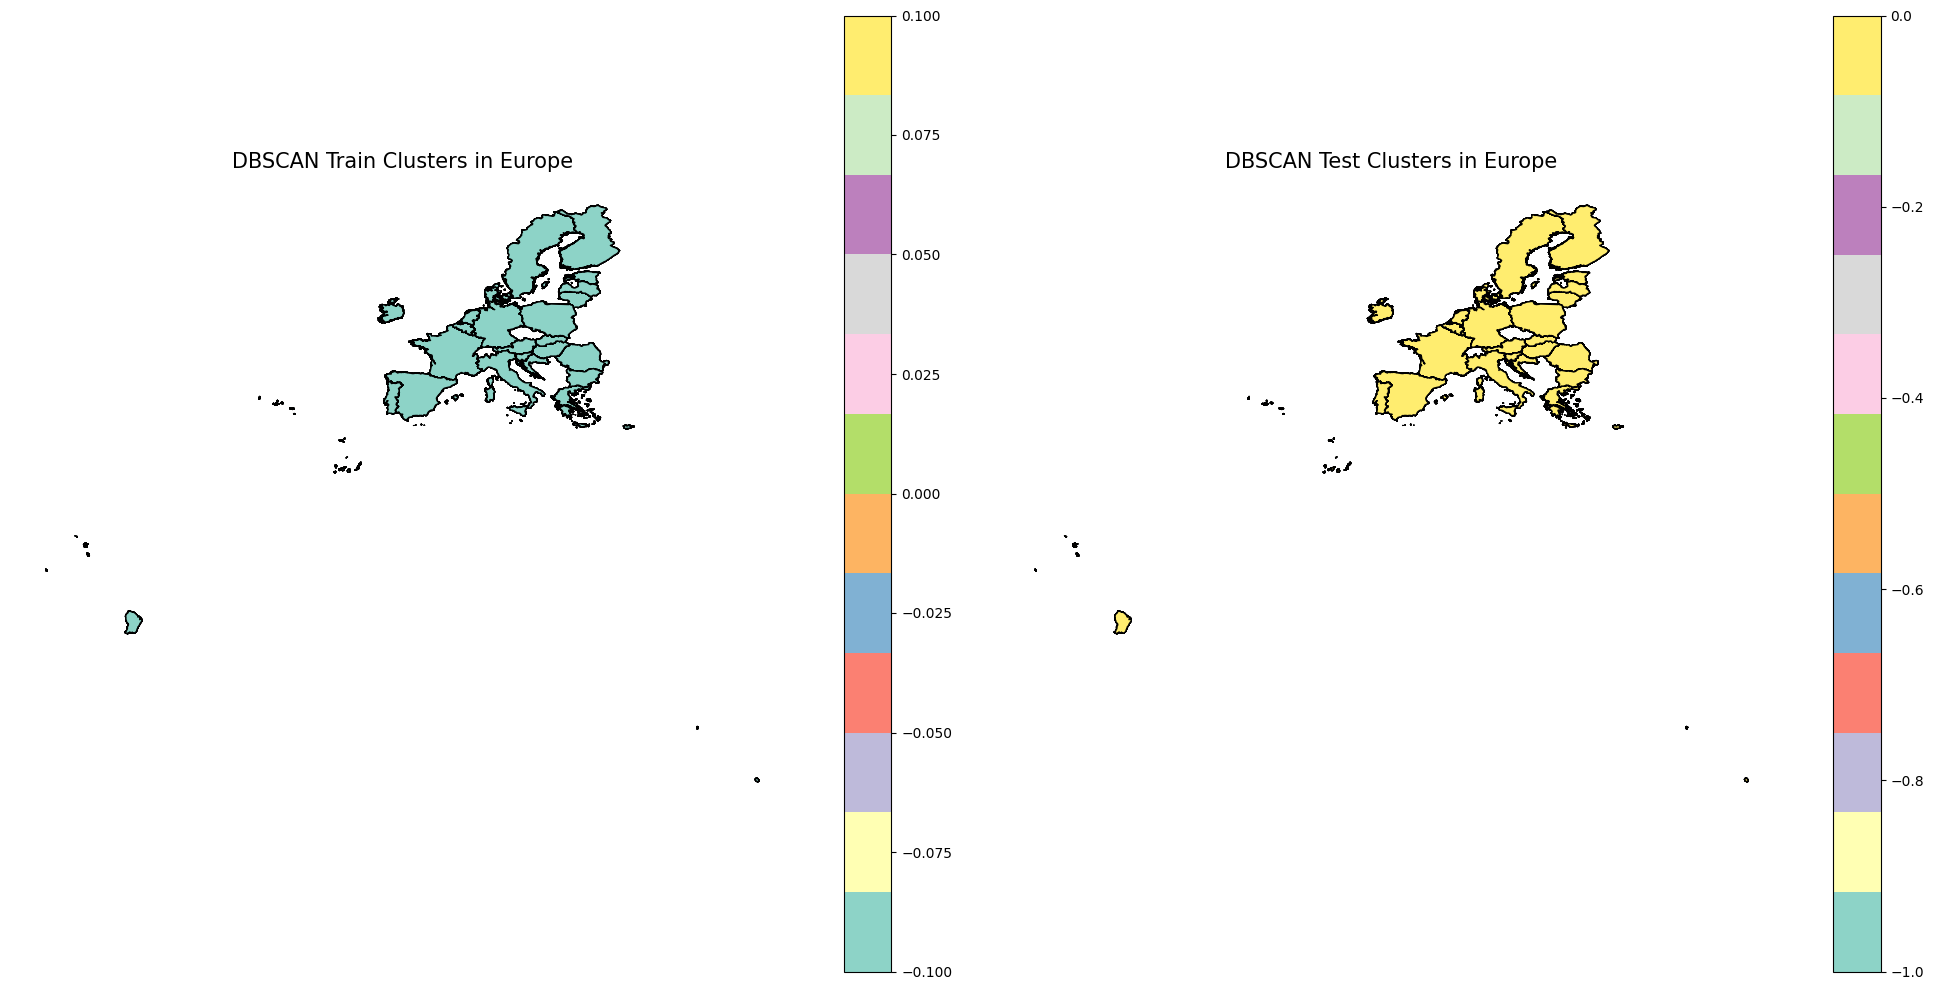

In [52]:
# DBSCAN: Train and Test-COVID
fig, axes = plt.subplots(1, 2, figsize=(20, 10))

# Plot Train Data
geo_data.plot(column='DBSCAN_Train',
              cmap='Set3',
              legend=True,
              ax=axes[0],
              edgecolor='black',
              missing_kwds={'color': 'lightgrey', 'label': 'No Data'})
axes[0].set_title("DBSCAN Train Clusters in Europe", fontsize=15)
axes[0].axis('off')

# Plot Test Data
geo_data.plot(column='DBSCAN_Test',
              cmap='Set3',
              legend=True,
              ax=axes[1],
              edgecolor='black',
              missing_kwds={'color': 'lightgrey', 'label': 'No Data'})
axes[1].set_title("DBSCAN Test Clusters in Europe", fontsize=15)
axes[1].axis('off')

plt.tight_layout()
plt.show()

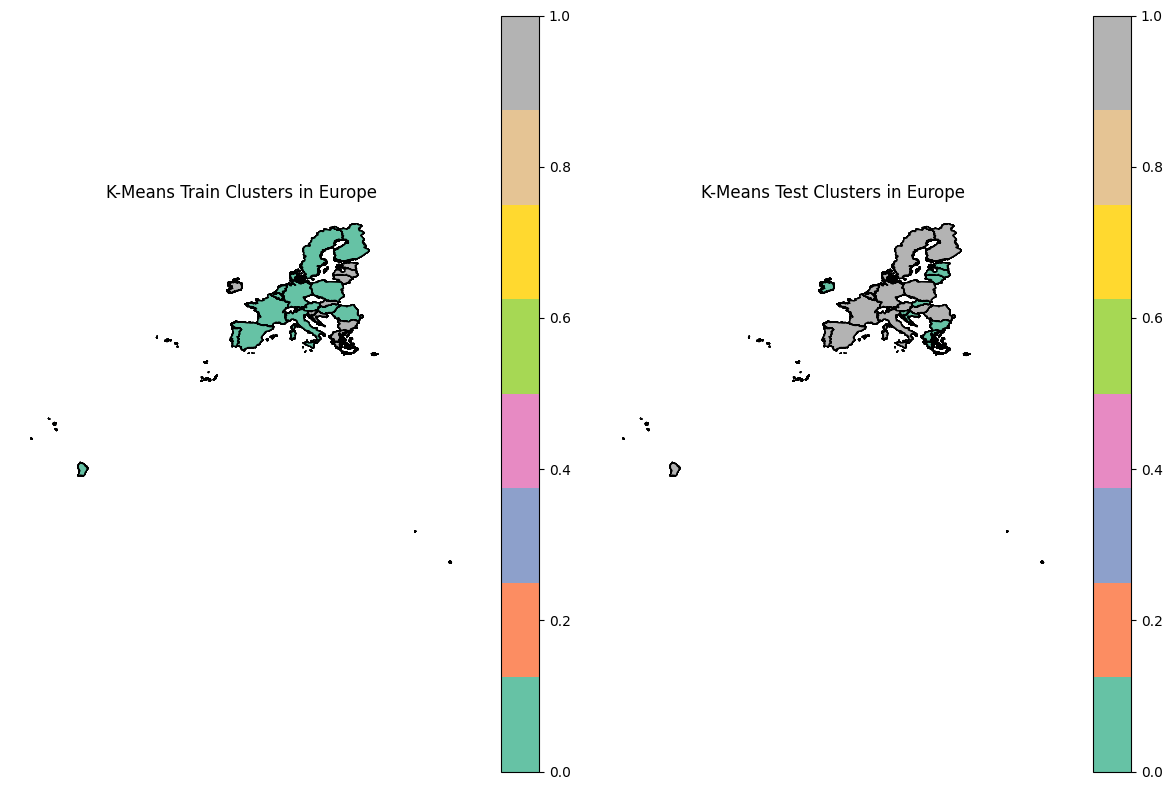

In [53]:
# K-Means: Train and Test-COVID

fig, axes = plt.subplots(1, 2, figsize=(12, 8))

geo_data.plot(column='KMeans_Train', cmap='Set2', legend=True, ax=axes[0], edgecolor='black')
axes[0].set_title("K-Means Train Clusters in Europe")
axes[0].axis('off')

geo_data.plot(column='KMeans_Test', cmap='Set2', legend=True, ax=axes[1], edgecolor='black')
axes[1].set_title("K-Means Test Clusters in Europe")
axes[1].axis('off')

plt.tight_layout()
plt.show()